In [1]:
import os
import sys
sys.path.insert(
    0, os.path.abspath('../../')
)

import json
import yaml
import random

from pathlib import Path
from rich.console import Console
from rich.table import Table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Demo: Sampling from Dirichlet Distribution

In [5]:
def sample_soft_label(num_classes: int,
                      strategy: str = "mixed",
                      ) -> np.ndarray:
    alpha_options = [
        [0.1] * num_classes,  # very spiky
        [0.3] * num_classes,  # spikier
        [0.5] * num_classes,  # slightly spiky
        [1.0] * num_classes,  # balanced        
        [5.0] * num_classes,  # very flat/high entropy
    ]
    if strategy == "very spiky":
        alpha = alpha_options[0]
    elif strategy == "spikier":
        alpha = alpha_options[1]
    elif strategy == "slightly spiky":
        alpha = alpha_options[2]
    elif strategy == "flat":
        alpha = alpha_options[3]
    elif strategy == "very flat":
        alpha = alpha_options[4]
    elif strategy == "mixed":
        alpha = random.choice(alpha_options)
    else:
        raise ValueError
    return np.random.dirichlet(alpha)

In [6]:
NUM_CLASSES = 6
NUM_SAMPLES = 10000
ALPHA_STRATEGIES = ["very spiky", "spikier", "slightly spiky", "flat", "very flat", "mixed"]

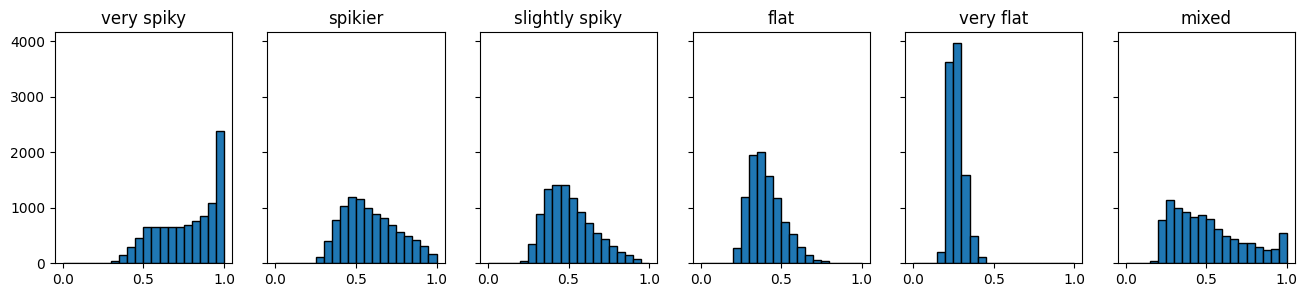

In [7]:
fig, axes = plt.subplots(1, len(ALPHA_STRATEGIES), figsize=(16, 3), sharey=True)

for i, alpha_strategy in enumerate(ALPHA_STRATEGIES):
    
    # sample soft labels
    y = np.array([sample_soft_label(NUM_CLASSES, alpha_strategy) for _ in range(NUM_SAMPLES)])
    y = y.max(axis=1)  # what is the largest probability obtainable?

    axes[i].hist(y, bins=np.arange(0, 1.01, 0.05), edgecolor='k')
    axes[i].set_title(alpha_strategy)

plt.show(fig)

## Load Real Data

In [8]:
root_dir = Path("../../").resolve()
print("Root directory:", root_dir)

Root directory: /home/hgkahng/Workspaces/soft-prompt


In [9]:
from typing import Union

def load_oracle_emotion_data(directory: Union[str, Path]
                             ) -> tuple[np.ndarray, np.ndarray]:
    
    _directory = Path(directory).resolve()

    X_train = np.load(_directory / "train.features.npy")
    y_train = np.load(_directory / "train.labels.npy")
    X_valid = np.load(_directory / "validation.features.npy")
    y_valid = np.load(_directory / "validation.labels.npy")
    X_test = np.load(_directory / "test.features.npy")
    y_test = np.load(_directory / "test.labels.npy")
    
    X = np.concatenate((X_train, X_valid, X_test), axis=0)
    y = np.concatenate((y_train, y_valid, y_test), axis=0)
    
    return X, y

oracle_embedding_dir = root_dir / "data/emotion/embeddings/openai/text-embedding-3-small"
X_test, y_test = load_oracle_emotion_data(oracle_embedding_dir)
print(X_test.shape, y_test.shape)

(20000, 1536) (20000,)


## Load Synthetic Data

In [11]:
sub_dir = root_dir / "results/emotion/dirichlet_analysis"
print(*sorted(os.listdir(sub_dir)), sep="\n")

0_very_spiky
1_spikier
2_slightly_spiky
3_flat
4_very_flat
5_mixed


In [ ]:
from typing import List, Dict, Tuple

def process_labels(data: List[Dict[str, list]]) -> Tuple[np.ndarray]:
    
    labels = [d['label'] for d in data]

    # Check for invalid labels
    mask = np.array([len(l) == 6 for l in labels])
    valid_idx = np.where(mask)[0]

    # Keep valid labels only
    labels = [l for i, l in enumerate(labels) if i in valid_idx]
    labels = np.array(labels)        # soft vectors 
    hard_labels = labels.argmax(axis=-1)  # label indicators
    soft_labels = labels / labels.sum(axis=1, keepdims=True)  # normalized
    assert soft_labels.sum(axis=1).all()  # check row sum = 1 (valid probabilities)

    return hard_labels, soft_labels, valid_idx

In [ ]:
import nltk; nltk.download('punkt_tab', quiet=True)

from softprompt.metrics.diversity import (
    vocabulary_size,
    distinct_n,
    average_pairwise_similarity,
    average_pairwise_similarity_by_class,
    inter_sample_ngram_freq,
)

In [55]:
alpha_to_data = {}

for alpha_type in sorted(os.listdir(sub_dir)):
    
    # specify the directory to load data from
    load_dir = sub_dir / alpha_type
    print(load_dir)
    
    # print configurations
    def print_config(load_dir: str) -> None:
        with open(load_dir / 'config.yaml') as f:
            cfg = yaml.safe_load(f)
        table = Table(title="Configuration(s)")
        table.add_column("Name", justify="right", style="white", no_wrap=True)
        table.add_column("Value", justify="left", style="cyan",)
        _ = [table.add_row(k, str(v)) for k, v in cfg.items()]
        console = Console()
        console.print(table);

    # print_config(load_dir)
    
    # load data
    def load_data(load_dir: str) -> list:
        with open(load_dir / 'data.jsonl', 'r') as f:
            data = [json.loads(line) for line in f]
        return data
    
    data = load_data(load_dir)

    # process labels
    y_syn_hard, y_syn_soft, valid_idx = process_labels(data)

    # load embeddings
    embeddings = np.load(
    load_dir / "embeddings/openai/text-embedding-3-small/data.npy"
    )
    embeddings = embeddings[valid_idx]
    
    # save data
    alpha_to_data[alpha_type] = {
        'text': [d['text'] for i, d in enumerate(data) if i in valid_idx],
        'embedding': embeddings,
        'soft_label': y_syn_soft,
        'hard_label': y_syn_hard, 
    }

/home/hgkahng/Workspaces/soft-prompt/results/emotion/dirichlet_analysis/0_very_spiky
/home/hgkahng/Workspaces/soft-prompt/results/emotion/dirichlet_analysis/1_spikier
/home/hgkahng/Workspaces/soft-prompt/results/emotion/dirichlet_analysis/2_slightly_spiky
/home/hgkahng/Workspaces/soft-prompt/results/emotion/dirichlet_analysis/3_flat
/home/hgkahng/Workspaces/soft-prompt/results/emotion/dirichlet_analysis/4_very_flat
/home/hgkahng/Workspaces/soft-prompt/results/emotion/dirichlet_analysis/5_mixed


In [56]:
alpha_to_data.keys()

dict_keys(['0_very_spiky', '1_spikier', '2_slightly_spiky', '3_flat', '4_very_flat', '5_mixed'])

In [ ]:
def filter_by_entropy(y: np.ndarray, max_entropy: float = 1.0) -> np.ndarray:
    assert y.ndim == 2, "Expects a 2d array probabilities for y"
    eps = 1e-10
    H = - np.sum(y * np.log(y + eps) / np.log(y.shape[1]), axis=-1)
    return H <= max_entropy  # spiky probs = small entropy (flat probs = large entropy)

In [58]:
import numpy as np
import copy
from typing import Tuple, Dict, Union, List, Optional

# Assuming these are available in your environment as per your existing code
from softprompt.metrics.evaluator import BinaryEvaluator, MulticlassEvaluator
from softprompt.algorithms.sklearn.linear_model import (
    SoftLogisticRegressionCV
)
# Standard sklearn LogisticRegressionCV
from sklearn.linear_model import LogisticRegressionCV


def evaluate_logreg_cv_experiment_multiclass(
    X_train_full: np.ndarray,
    y_train_full_probs: np.ndarray,  # Original training labels as probabilities
    X_test: np.ndarray,
    y_test_hard: np.ndarray,         # Test labels, already hard (0 or 1)
    subsample_size: int,
    model_variant: str,              # 'soft' or 'standard'
    Cs: Union[int, List[float], np.ndarray] = 10,
    cv_folds: int = 5,
    solver: str = 'lbfgs',
    max_iter_solver: int = 1000,
    n_jobs_cv: Optional[int] = 8,
    base_random_seed: int = 42,
    bootstrap: bool = True,
    n_trials: int = 50
) -> Tuple[Dict[str, List[float]], Dict[str, List[float]]]:

    if X_train_full.shape[0] != len(y_train_full_probs):
        raise ValueError("X_train_full and y_train_full_probs must have the same number of samples.")
    if model_variant not in ['soft', 'standard', 'gce']:
        raise ValueError("model_variant must be 'soft' or 'standard'.")

    evaluator = MulticlassEvaluator()
    
    # Initialize dictionaries to store metric arrays for each trial
    # The keys will be metric names from evaluator.metrics_to_compute
    # This assumes evaluator.metrics_to_compute is available and populated before this call
    if not hasattr(evaluator, 'metrics_to_compute') or not evaluator.metrics_to_compute:
        # Fallback if metrics_to_compute is not set, use a default or raise error
        # For demonstration, let's assume some common metrics if not available.
        # In a real scenario, BinaryEvaluator should define this.
        print("Warning: evaluator.metrics_to_compute not found or empty. Using default metrics for collection: ['accuracy', 'roc_auc']")
        default_metrics = ['accuracy', 'roc_auc'] # Example
        tr_metric_to_array = {m: np.empty(n_trials) for m in default_metrics}
    else:
        tr_metric_to_array = {m: np.empty(n_trials) for m in evaluator.metrics_to_compute}
    te_metric_to_array = copy.deepcopy(tr_metric_to_array)

    full_idx = np.arange(X_train_full.shape[0])
    
    # Convert full y_train_full_probs to hard labels for evaluation consistency
    y_train_full_hard_for_eval = y_train_full_probs.argmax(axis=-1)

    for i in range(n_trials):
        current_trial_seed = base_random_seed + i
        rng = np.random.default_rng(current_trial_seed)

        # Get sub-sampled indices to use for training
        if bootstrap:
            subsample_idx = rng.choice(full_idx, size=subsample_size, replace=True)
        else:
            subsample_idx = rng.permutation(full_idx)[:subsample_size]

        X_train_subsample = X_train_full[subsample_idx]
        y_train_subsample_probs = y_train_full_probs[subsample_idx]

        # Fit model
        if model_variant == 'soft':
            lg = SoftLogisticRegressionCV(
                Cs=Cs, cv=cv_folds, solver=solver,
                max_iter=max_iter_solver, n_jobs=n_jobs_cv,
                random_state=current_trial_seed,
            )
            # Prepare P_train for soft labels (num_samples, num_classes)
            # Assuming binary classification where y_train_subsample_probs are probs of class 1
            if y_train_subsample_probs.ndim == 1:
                 P_train_fit = np.stack(
                    [1 - y_train_subsample_probs, y_train_subsample_probs], axis=1
                )
            elif y_train_subsample_probs.ndim == 2 and y_train_subsample_probs.shape[1] == 2:
                 P_train_fit = y_train_subsample_probs # Assume it's already [prob_class_0, prob_class_1]
            else:
                raise ValueError(
                    "y_train_subsample_probs must be 1D (probs for class 1)"
                    " or 2D with shape (n_samples, 2)."
                )

            lg.fit(X_train_subsample, P_train_fit);

        else:
            lg = LogisticRegressionCV(
                Cs=Cs, cv=cv_folds, solver=solver,
                max_iter=max_iter_solver, n_jobs=n_jobs_cv,
                random_state=current_trial_seed,
                penalty='l2',  # Assuming L2 penalty to align with SoftLogisticRegression
                scoring='neg_log_loss' # To align CV optimization goal with 'cross_entropy'
            )
            # Standard LogisticRegressionCV expects 1D hard labels for y
            y_train_fit_hard = y_train_subsample_probs.argmax(axis=-1)
            lg.fit(X_train_subsample, y_train_fit_hard)

        # Evaluate on the full training set
        # The evaluator expects y_true as hard labels and y_prob as predicted probabilities
        tr_metrics_i = evaluator(
            y_true=y_train_full_hard_for_eval, # Hard labels from original full y_train
            y_prob=lg.predict_proba(X_train_full)
        )
        for m, v in tr_metrics_i.items():
            if m in tr_metric_to_array:
                 tr_metric_to_array[m][i] = v

        # Evaluate on the test set
        te_metrics_i = evaluator(
            y_true=y_test_hard, # y_test is already hard labels
            y_prob=lg.predict_proba(X_test)
        )
        for m, v in te_metrics_i.items():
            if m in te_metric_to_array:
                te_metric_to_array[m][i] = v
    
    # Aggregate metrics (train)
    tr_out_agg = {}
    for m, arr in tr_metric_to_array.items():
        if not np.all(np.isnan(arr)): # Ensure array is not all NaNs before mean/std
            tr_out_agg[m] = [np.nanmean(arr), np.nanstd(arr, ddof=1)]
        else:
            tr_out_agg[m] = [np.nan, np.nan]


    # Aggregate metrics (test)
    te_out_agg = {}
    for m, arr in te_metric_to_array.items():
        if not np.all(np.isnan(arr)):
            te_out_agg[m] = [np.nanmean(arr), np.nanstd(arr, ddof=1)]
        else:
            te_out_agg[m] = [np.nan, np.nan]

    return tr_out_agg, te_out_agg

In [68]:
alpha_type_to_entropy = {}

for alpha_type, data in alpha_to_data.items():
    
    console = Console()
    console.rule(alpha_type)

    # vocabulary size
    vocab_size = vocabulary_size(data['text'])
    print(f"Vocab: {vocab_size:,}")

    # distinct-n
    distinct_2 = distinct_n(data['text'], n=2)
    print(f"Distinct-2: {distinct_2:.4f}")

    # average pairwise similarity (un-conditional)
    aps = average_pairwise_similarity(data['embedding'])
    print(f"APS: {aps:4f}")

    # inter/intra-class APS
    # inter_aps, intra_aps = \
    #     average_pairwise_similarity_by_class(data['embedding'], data['hard_label'])
    # print(f"Inter-class APS: {inter_aps:.4f}")
    # print(f"Intra-class APS: {intra_aps:.4f}")

    X_syn = data['embedding'].copy()
    y_syn_soft = data['soft_label'].copy()
    y_syn_hard = data['hard_label'].copy()

    entropy_to_metrics = {}
    max_entropies = (1.0, 0.9, 0.8, 0.7, 0.6, 0.5)
    for e in max_entropies:
        
        # compute entropy mask
        entropy_mask = filter_by_entropy(data['soft_label'], max_entropy=e)
        effective_indices = np.where(entropy_mask)[0] 
        if len(effective_indices) == 0:
            console.print(f">> Effective pool size is 0 with max_entropy = {e:.2f}. Skipping.")
            entropy_to_metrics[e] = {'train': [], 'test': []}  # store empty
            continue

        X_syn_filtered = X_syn[effective_indices]
        y_syn_soft_filtered = y_syn_soft[effective_indices] # This is 1D
        N_filtered = len(X_syn_filtered)
        console.print(f">> Effective pool size is {N_filtered:,} with max_entropy = {e:.2f}")

        # Store metrics for this margin across different subsample ratios
        train_metrics_for_all_ratios: Dict[str, List[List[float]]] = {}
        test_metrics_for_all_ratios: Dict[str, List[List[float]]] = {}

        N = N_filtered
        ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
        ratios = (1.00, )
        subsample_sizes = [int(N * r) for r in ratios]

        for i, subsample_size in enumerate(subsample_sizes):

            console.print(
                f"Subsample Ratio: {ratios[i]:.2f} (Size: {subsample_size:,})"
            )
            try:
                tr_metrics, te_metrics = evaluate_logreg_cv_experiment_multiclass(
                    X_train_full=X_syn,
                    y_train_full_probs=y_syn_soft,
                    X_test=X_test,
                    y_test_hard=y_test,
                    subsample_size=subsample_size,
                    model_variant='standard',
                    bootstrap=True,
                    n_trials=5,
                )
            except ValueError as e:
                print(f"Skipping subsample size {i} (Error: {e})")
            # Store all metrics for this ratio
            for metric_name, (mean_val, std_val) in tr_metrics.items():
                if metric_name not in train_metrics_for_all_ratios:
                    train_metrics_for_all_ratios[metric_name] = []
                train_metrics_for_all_ratios[metric_name].append([mean_val, std_val])
            
            for metric_name, (mean_val, std_val) in te_metrics.items():
                if metric_name not in test_metrics_for_all_ratios:
                    test_metrics_for_all_ratios[metric_name] = []
                test_metrics_for_all_ratios[metric_name].append([mean_val, std_val])

            from rich.table import Table
            table = Table(title=f"Metrics (e={e:.2f}, r={ratios[i]:.2f})")
            table.add_column("Metric Name", style='cyan', no_wrap=True, justify='left')
            table.add_column("Train", style='blue', justify='center')
            table.add_column("Test", style='white', justify='center')
            for name in tr_metrics.keys():
                tr_mean_, tr_std_ = tr_metrics[name]
                tr_metric_value_str = f"{tr_mean_:.4f} (± {tr_std_:.4f})"
                te_mean_, te_std_ = te_metrics[name]
                te_metric_value_str = f"{te_mean_:.4f} (± {te_std_:.4f})"
                table.add_row(
                    name,
                    tr_metric_value_str,
                    te_metric_value_str,
                )
            console.print(table);

        entropy_to_metrics[e] = {
            'train': train_metrics_for_all_ratios,
            'test': test_metrics_for_all_ratios,
        }

    alpha_type_to_entropy[alpha_type] = entropy_to_metrics


────────────────────────────────────────────────── 0_very_spiky ───────────────────────────────────────────────────

Vocab: 3,259
Distinct-2: 0.1010
APS: 0.349680


>> Effective pool size is 10,000 with max_entropy = 1.00

Subsample Ratio: 1.00 (Size: 10,000)

               Metrics (e=1.00, r=1.00)                
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9625 (± 0.0026) │ 0.3611 (± 0.0480) │
│ precision   │ 0.9625 (± 0.0026) │ 0.3488 (± 0.0149) │
│ recall      │ 0.9625 (± 0.0026) │ 0.3591 (± 0.0169) │
│ f1_score    │ 0.9625 (± 0.0026) │ 0.3155 (± 0.0319) │
│ roc_auc     │ 0.9977 (± 0.0001) │ 0.7107 (± 0.0147) │
│ auprc       │ 0.9900 (± 0.0006) │ 0.3279 (± 0.0193) │
│ ece         │ 0.0045 (± 0.0004) │ 0.1591 (± 0.0289) │
└─────────────┴───────────────────┴───────────────────┘

...

Subsample Ratio: 1.00 (Size: 415)

               Metrics (e=0.90, r=1.00)                
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.6626 (± 0.0061) │ 0.3944 (± 0.0483) │
│ precision   │ 0.6621 (± 0.0056) │ 0.3643 (± 0.0398) │
│ recall      │ 0.6628 (± 0.0061) │ 0.3374 (± 0.0142) │
│ f1_score    │ 0.6609 (± 0.0066) │ 0.3128 (± 0.0156) │
│ roc_auc     │ 0.9143 (± 0.0020) │ 0.7161 (± 0.0088) │
│ auprc       │ 0.7048 (± 0.0063) │ 0.3354 (± 0.0134) │
│ ece         │ 0.0219 (± 0.0045) │ 0.0911 (± 0.0207) │
└─────────────┴───────────────────┴───────────────────┘

>> Effective pool size is 2 with max_entropy = 0.80

Subsample Ratio: 1.00 (Size: 2)

ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.